# KNS skew swap replication under SABR

Build the Kozhan–Neuberger–Schneider (RFS 2013) skew swap strip from European options, hedge it along SABR paths
whose real-world correlation $\rho_{sim}$ differs from the pricing correlation $\rho_{imp}$, and inspect the rebalancing.

All logic lives in the project modules (`sabr`, `strip`, `simulate`, `hedge`, `analysis`, `plots`, `explorer`);
this notebook only sets parameters, runs, and displays. See `README.md` for the derivations and the reference results.

## 1. Setup

Imports, inline matplotlib, and the plotly renderer. Inside VS Code the kernel inherits `VSCODE_*` environment
variables, so the renderer is set to `"vscode"`; in classic Jupyter / JupyterLab it falls back to `"notebook"`.
If plotly figures stay blank, set `pio.renderers.default = "notebook_connected"` and re-run the explorer cell.

`autoreload` picks up edits to the `.py` modules without restarting the kernel.

In [45]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning, module="kaleido")  # plotly 5 / kaleido 1 mismatch: only affects write_image

PROJECT = Path.cwd() if (Path.cwd() / "sabr.py").exists() else Path.cwd() / "skew_swap"
sys.path.insert(0, str(PROJECT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from tqdm.auto import tqdm
from IPython.display import display

import analysis as an
from config import Config
from hedge import Variant
from plots import fig_initial, fig_distribution
from explorer import path_explorer

pio.renderers.default = "vscode" if any(k.startswith("VSCODE_") for k in os.environ) else "notebook"
pd.options.display.float_format = "{:.4g}".format
print("project:", PROJECT, "| plotly renderer:", pio.renderers.default)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project: /Users/kevinlaventure/python_code/skew_swap | plotly renderer: vscode


### Parameters

Every parameter in one place — edit and re-run from here. Results are cached on disk under `cache/`, keyed on the
full `Config`, so changing any value triggers a fresh simulation while re-running with unchanged values just reloads.

* `rho_imp` prices every option (the market smile); `rho_sim` drives the simulated paths.
* `rebalance` is the default variant shown in the explorer; all three are always run.
* `delta_mode`: `"sticky_alpha"` (FD in $F$, $\alpha$ fixed) or `"bartlett"` (adds $\partial_\alpha V\,\rho_{imp}\nu/F^\beta$).

In [46]:
cfg = Config(
    # SABR (pricing uses rho_imp; the diffusion uses rho_sim)
    F0=100.0, T=0.5, n_steps=126, beta=1.0, alpha0=0.20, nu=0.8,
    rho_imp=-0.70, rho_sim=-0.50,
    # strike grid
    K_min=30.0, K_max=300.0, K_step=1.0,
    # Monte Carlo
    n_paths=2000, seed=42,
    # hedging
    rebalance="step",           # explorer default: "step" | "threshold" | "none"
    threshold=0.03,             # threshold variant re-centres when |F_t/F_last - 1| > threshold
    delta_mode="sticky_alpha",  # "sticky_alpha" | "bartlett"
    bid_ask_vol=0.0,            # full bid-ask in vol points (0.01 = 1 vol pt)
)
CACHE_DIR = PROJECT / "cache"
REFRESH = False                 # True forces re-simulation even if a cache file exists
cfg

Config(F0=100.0, T=0.5, n_steps=126, beta=1.0, alpha0=0.2, nu=0.8, rho_imp=-0.7, rho_sim=-0.5, K_min=30.0, K_max=300.0, K_step=1.0, n_paths=2000, seed=42, delta_mode='sticky_alpha', rebalance='step', threshold=0.03, bid_ask_vol=0.0, fd_F=0.001, fd_alpha=0.001, fd_rho=0.01, path_id=0, n_log_paths=10, out_dir='output')

## 2. Initial portfolio (priced with $\rho_{imp}$)

With zero rates, spot = forward $F$, and $\mathrm{OTM}(K)$ = put if $K<F$ else call:

$$v^L = 2\int \frac{\mathrm{OTM}(K)}{K^2}\,dK = \mathbb{E}\big[-2\ln\tfrac{F_T}{F}\big],\qquad
v^E = 2\int \frac{\mathrm{OTM}(K)}{K\,F}\,dK = \mathbb{E}\big[2\tfrac{F_T}{F}\ln\tfrac{F_T}{F}\big]$$

The KNS strip holds $w(K) = \dfrac{6(K-F_0)}{K^2F_0} = \dfrac{6}{KF_0}-\dfrac{6}{K^2}$ OTM options per unit strike, so its value is the
implied skew $3(v^E - v^L) = \mathbb{E}[6G(x_T)] \approx \mathbb{E}[x_T^3]$ with $G(x) = xe^x - 2e^x + x + 2$.

Integrals are trapezoidal on the strike grid; the wider grids measure the truncation error (weights grow like $1/K^2$ in the put wing).

In [47]:
print(f"ATM vol {an.atm_vol(cfg):.4f}   E_Q[∫σ²dt] (exact, β=1) = {cfg.alpha0**2 * np.expm1(cfg.nu**2 * cfg.T) / cfg.nu**2:.6f}")
an.initial_portfolio_table(cfg)

ATM vol 0.1986   E_Q[∫σ²dt] (exact, β=1) = 0.023570


,v^L,v^E,3(v^E − v^L),Σ q·OTM,skew error vs widest,skew error %
config 30..300 step 1,0.02389,0.02218,-0.005148,-0.005148,9.432e-05,-1.799
wide 5..1000 step 1,0.02393,0.02219,-0.005241,-0.005241,1.06e-06,-0.02023
wide 1..3000 step 0.25,0.02392,0.02217,-0.005242,-0.005242,0,-0


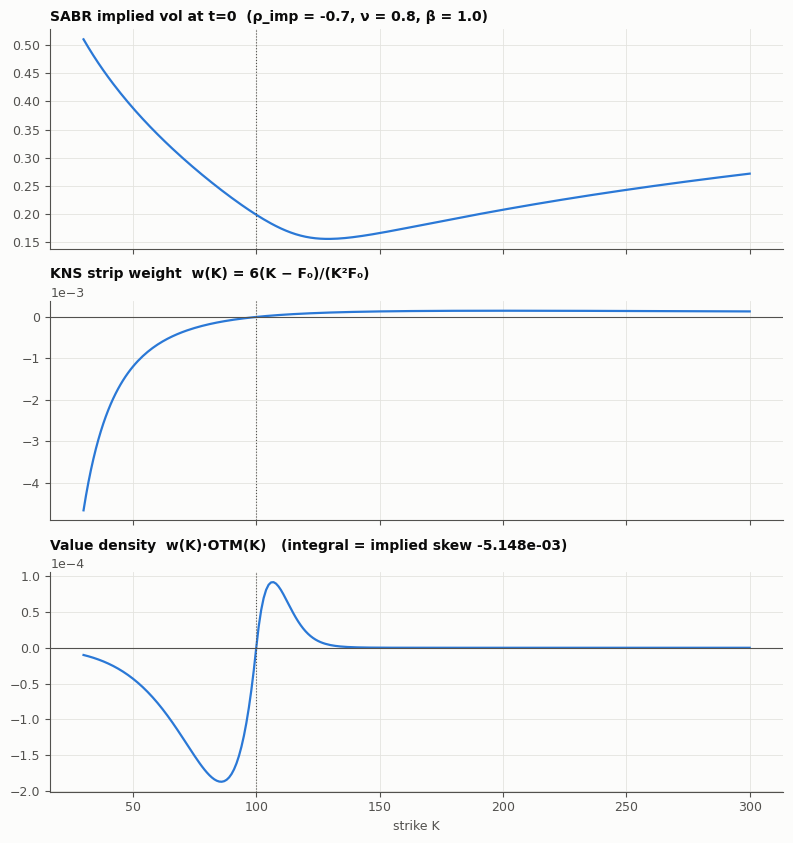

In [48]:
fig_initial(cfg)
plt.show()

## 3. Simulation and rebalancing

**Diffusion** ($\rho_{sim}$): $dF = \sigma F^\beta dW_1$, $d\sigma = \nu\sigma\,dW_2$, $\mathrm{corr}(dW_1,dW_2)=\rho_{sim}$, log-Euler on both.
Every step, every option is repriced with Hagan SABR at the current state ($\alpha=\sigma_t$, $\tau=T-t$) but market parameters ($\rho_{imp}$, $\nu$, $\beta$).

**Rebalancing** at each step:
1. *Parity relabel*: options whose strike $F_t$ crossed are converted to the same-strike OTM option ($C = P + F - K$); the ±1 forward is logged separately.
2. *Option re-centring* (`step`: every step · `threshold`: when $|F_t/F_{last}-1|>x$ · `none`: never): move to $w_t(K)=6(K-F_t)/(K^2F_t)$,
   i.e. trade $6\,(1/F_t - 1/F_{last})/K$ at each strike — one sign across strikes.
3. *Delta hedge*: forwards to zero total book delta.

**Realised leg**: $RS = \sum_i \big[3\,\delta v^E_i\,(e^{\delta f_i}-1) + 6\,G(\delta f_i)\big]$, and the replication identity is
hedged P&L $\approx RS - 3(v^E - v^L)_0$.

All variants share the per-step price grids, so they run in one pass; the result is cached to `cache/*.pkl`.

In [49]:
variants = [Variant(r, cfg.delta_mode) for r in an.REBALANCES]
res = an.cached("mc", (cfg, variants), lambda: an.simulate_and_run(cfg, variants, progress=tqdm),
                cache_dir=CACHE_DIR, refresh=REFRESH)
primary = f"{cfg.rebalance}/{cfg.delta_mode}"
an.benchmark_summary(res).to_frame("value")

,value
S0 = 3(vE−vL)_0,-0.005148
mean RS,-0.003385
s.e. RS,8.63e-05
mean RS − S0,0.001763
mean realised spot-vol corr,-0.4854
std realised spot-vol corr,0.06499


## 4. Single-path explorer

Pick a path (box or slider), a variant, or draw a random path. The selected path is re-run with full per-strike logging
(identical to its row in the cached run, a fraction of a second).

Panels, top to bottom: $F_t$ and $\sigma_t$ (orange dots = option re-centring dates) · option trades heatmap (strike × time,
blue bought / red sold, $t=0$ purchase omitted, $F_t$ in black; hover gives strike, quantity, put/call) · forward trades
(delta hedge vs parity relabel) and position · book Greeks — cash gamma $\Gamma F^2$, vega $\partial_\alpha V$, vanna $\partial^2_{F\alpha}V$,
skew exposure $\Delta V$ for $\rho_{imp}+0.01$ — for the chosen variant (solid) vs no option rebalancing (dashed) ·
cumulative P&L split into option MTM, forward hedge, costs, against the running benchmark
$RS_t + 3(v^E-v^L)_t - 3(v^E-v^L)_0$ · tracking error.

In [50]:
path_explorer(res, variant=primary)

## 5. Cross-path results

**Distribution.** Final P&L of the long strip / receive-realised book per variant, with $RS - 3(v^E-v^L)_0$ shaded behind;
and final P&L against the path's realised correlation of $d\ln F$ and $d\ln\sigma$ (dotted lines at $\rho_{imp}$, $\rho_{sim}$).
With $\rho_{sim} > \rho_{imp}$ realised skew is less negative than implied, so the mean should be positive.

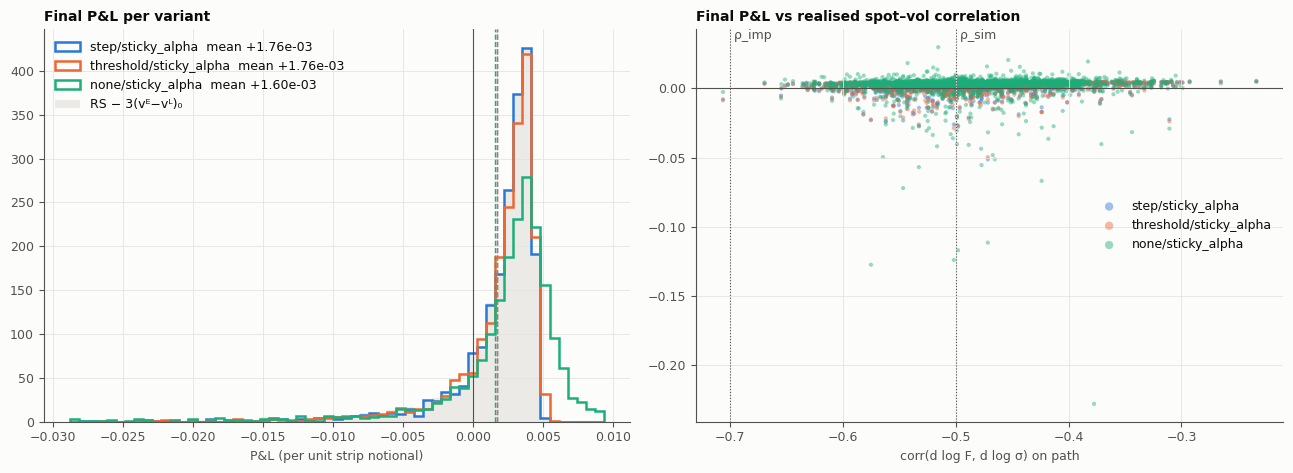

In [51]:
fig_distribution(res, list(res["books"]))
plt.show()

**P&L and tracking error per variant.** Tracking error $TE = \text{P\&L} - (RS - S_0)$ with $S_0 = 3(v^E-v^L)_0$.

In [52]:
an.variant_table(res)

,mean P&L,s.e.,std P&L,TE mean,TE std,rebalances/path,"corr(P&L, realised ρ)"
step/sticky_alpha,0.001757,8.395e-05,0.003754,-5.994e-06,0.0008019,125,0.1644
threshold/sticky_alpha,0.001762,8.559e-05,0.003828,-3.739e-07,0.001047,14.01,0.1607
none/sticky_alpha,0.0016,0.0002249,0.01006,-0.0001625,0.008773,0,0.02436


**Vega drift.** Book vega in units of $\partial_\alpha v^E$, minus the fresh strip's own skew vega
$3(\partial_\alpha v^E - \partial_\alpha v^L)/\partial_\alpha v^E$, regressed on $3(F_t/F_0-1)$. Re-centring keeps it at 0;
without it the book carries $3(F_t/F_0-1)$ entropy contracts (slope 1).

In [53]:
an.vega_table(res, cfg.delta_mode)

,intercept,slope on 3(F_t/F0−1),R²,std(excess vega),std 3(F_t/F0−1)
step/sticky_alpha,-8.475e-19,-2.181e-18,2.474e-06,4.302e-16,0.3102
threshold/sticky_alpha,0.0004705,0.01819,0.01903,0.04092,0.3102
none/sticky_alpha,-2.707e-18,1,1,0.3102,0.3102


**Sanity: $\rho_{sim} = \rho_{imp}$.** The mean P&L should be ≈ 0 if the Hagan surface were a martingale price for the SABR
diffusion. At $\nu = 0.8$ it is not exactly: any residual mean here is Hagan approximation bias, to be netted off the
$\rho_{sim}\neq\rho_{imp}$ result above.

In [54]:
cfg_eq = cfg.with_(rho_sim=cfg.rho_imp)
res_eq = an.cached("mc", (cfg_eq, variants), lambda: an.simulate_and_run(cfg_eq, variants, progress=tqdm),
                   cache_dir=CACHE_DIR, refresh=REFRESH)
display(an.benchmark_summary(res_eq).to_frame("ρ_sim = ρ_imp"))
an.variant_table(res_eq)

,ρ_sim = ρ_imp
S0 = 3(vE−vL)_0,-0.005148
mean RS,-0.004724
s.e. RS,0.0001132
mean RS − S0,0.0004235
mean realised spot-vol corr,-0.6808
std realised spot-vol corr,0.04682


,mean P&L,s.e.,std P&L,TE mean,TE std,rebalances/path,"corr(P&L, realised ρ)"
step/sticky_alpha,0.0004092,0.0001119,0.005006,-1.426e-05,0.001196,125,0.1203
threshold/sticky_alpha,0.0003972,0.000115,0.005145,-2.635e-05,0.001382,14.08,0.1162
none/sticky_alpha,0.0002751,0.0002793,0.01249,-0.0001484,0.01054,0,-0.01173


**Convergence.** Tracking-error std vs `n_steps` (500 paths), and vs the strike grid for the `step` variant — the latter
shows the residual TE of the every-step book is strike truncation, not time discretisation.

In [55]:
conv = an.cached("conv", cfg, lambda: an.convergence_table(cfg, progress=tqdm), cache_dir=CACHE_DIR, refresh=REFRESH)
grid = an.cached("grid", cfg, lambda: an.grid_table(cfg, progress=tqdm), cache_dir=CACHE_DIR, refresh=REFRESH)
display(conv)
grid

,step TE std,threshold TE std,none TE std
n_steps,,,
63,0.0003054,0.0008598,0.006241
126,0.0002482,0.0007584,0.005797
252,0.0001502,0.0006723,0.004343


,TE mean,TE std
K = 30..300 step 1,1.032e-05,0.0002482
K = 5..1000 step 1,-3.436e-08,6.274e-06
K = 5..1000 step 0.25,1.885e-07,1.462e-06


## 6. Conclusions